<a href="https://www.kaggle.com/code/voropanovae/s6e4-irrigation-need-dt-rf-xgboost-score-0-9669?scriptVersionId=309105956" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction

This notebook presents several modelling approaches for the recent Playground Competition: Predicting Irrigation Need, both on the original dataset and the competition synthetic dataset, with a grid search to optimize the parameters.
The descriptive statistics for the Original and the Synthetic Train Datasets were explored in [our previous notebook](https://www.kaggle.com/code/voropanovae/s6e4-eda-dataviz-for-original-playground-data).

In a nutshell, these models achieved better balanced accuracy scores when trained on the synthetic dataset rather than the original dataset (public score of 0.9669). The best performance was achieved with a simple XGBoost model. However, a simple Decision Tree model trained on the synthetic dataset also showed a relatively good performance of 0.96422 (public score for the test dataset prediction), with a very reasonable computation cost.

This notebook is structured as follows:

* Library Imports and Data Loading
* Data Transformation
* Decision Tree Modelling
* Random Forest Modelling
* XGBoost Classification Modelling

# Library Imports and Data Loading

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import numpy as np 
import pandas as pd 

#Metrics
from sklearn import metrics
from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Data Preprocessing
from mlxtend.preprocessing import minmax_scaling
from sklearn.preprocessing import OneHotEncoder
#DecisionTree and RandomForest Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Train-test split
from sklearn.model_selection import train_test_split
#XGBoost Classifier
from xgboost import XGBClassifier

#Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

print("Setup complete")

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv
/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv
Setup complete


In [2]:
synthetic_link ='/kaggle/input/competitions/playground-series-s6e4/train.csv'
data_train_synthetic = pd.read_csv(synthetic_link, index_col="id")
original_link = "/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv"
test_link = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
data_train_original = pd.read_csv(original_link)

data_test = pd.read_csv(test_link, index_col="id")
print("Files loaded successfully!")

Files loaded successfully!


In [3]:
print(f"Shape of the original dataset: {data_train_original.shape}, \nShape of the synthetic dataset: {data_train_synthetic.shape}, \nShape of the test dataset: {data_test.shape}")

Shape of the original dataset: (10000, 20), 
Shape of the synthetic dataset: (630000, 20), 
Shape of the test dataset: (270000, 19)


In [4]:
print(f"Sum of NaN values in the original dataset: {data_train_original.isna().sum().sum()}, \nSum of NaN values in the synthetic dataset: {data_train_synthetic.isna().sum().sum()}, \nSum of NaN values in the test dataset: {data_test.isna().sum().sum()}")

Sum of NaN values in the original dataset: 0, 
Sum of NaN values in the synthetic dataset: 0, 
Sum of NaN values in the test dataset: 0


# Data Transformation

The following cell transforms the verbal labels of the target into integer labels, and transforms the verbal labels of "Mulching_Used" variable to binary integer levels.

In [5]:
low_medium_high_mapping = {
    "Low" : 0,
    "Medium" : 1,
    "High" : 2
}

inverse_low_medium_high_mapping = {
    0 : "Low",
    1 : "Medium",
    2 : "High"
}

yes_or_no_mapping = {
    "Yes" : 1,
    "No" : 0
}


data_train_original["Irrigation_Need"] = data_train_original["Irrigation_Need"].map(low_medium_high_mapping)
data_train_synthetic["Irrigation_Need"] = data_train_synthetic["Irrigation_Need"].map(low_medium_high_mapping)

data_train_original["Mulching_Used"] = data_train_original["Mulching_Used"].map(yes_or_no_mapping)
data_train_synthetic["Mulching_Used"] = data_train_synthetic["Mulching_Used"].map(yes_or_no_mapping)
data_test["Mulching_Used"] = data_test["Mulching_Used"].map(yes_or_no_mapping)


The following cell defines the lists of variables by their type, and prints these lists out.

In [6]:
# Get the list of train data boolean variables ("bool")
bool = (data_train_synthetic.dtypes == 'bool')
bool_cols = list(bool[bool].index)

print("List of the train data booleans:")
print(bool_cols)

# Get the list of train data qualitative variables ("object")
s = (data_train_synthetic.dtypes == 'object')
object_cols = list(s[s].index)

print("List of the train data objects:")
print(object_cols)

# Get the list of train data float variables ("float64")
fl = (data_train_synthetic.dtypes == 'float64')
float_cols = list(fl[fl].index)

print("List of the train data 'float64':")
print(float_cols)

# Get the list of train data integer variables ("int64")
i = (data_train_synthetic.dtypes == 'int64')
integer_cols = list(i[i].index)

print("List of the train data 'int64':")
print(integer_cols)

List of the train data booleans:
[]
List of the train data objects:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']
List of the train data 'float64':
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
List of the train data 'int64':
['Mulching_Used', 'Irrigation_Need']


The following cell applies One Hot Encoding to the three remaining object variables having different label encodings.

In [7]:
one_hot_cols_train = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']

# Apply one-hot encoder to each column with categorical data
OH_encoder_train = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype = int)
OH_cols_train_original = pd.DataFrame(OH_encoder_train.fit_transform(data_train_original[one_hot_cols_train]),
                            columns=OH_encoder_train.get_feature_names_out(one_hot_cols_train))
OH_cols_train_synthetic = pd.DataFrame(OH_encoder_train.fit_transform(data_train_synthetic[one_hot_cols_train]),
                            columns=OH_encoder_train.get_feature_names_out(one_hot_cols_train))

# One-hot encoding removed index; put it back
OH_cols_train_synthetic.index = data_train_synthetic.index
OH_cols_train_original.index = data_train_original.index

# Remove categorical columns (will replace with one-hot encoding)
num_data_train_original = data_train_original.drop(one_hot_cols_train, axis=1)
num_data_train_synthetic = data_train_synthetic.drop(one_hot_cols_train, axis=1)

# Add one-hot encoded columns to numerical features
data_train_original = pd.concat([num_data_train_original, OH_cols_train_original], axis=1)
data_train_synthetic = pd.concat([num_data_train_synthetic, OH_cols_train_synthetic], axis=1)


In [8]:
one_hot_cols_test = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']
# Apply one-hot encoder to each column with categorical data
OH_encoder_test = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype = int)
OH_cols_test = pd.DataFrame(OH_encoder_test.fit_transform(data_test[one_hot_cols_test]),
                           columns=OH_encoder_test.get_feature_names_out(one_hot_cols_test))
# One-hot encoding removed index; put it back
OH_cols_test.index = data_test.index
# Remove categorical columns (will replace with one-hot encoding)
num_data_test = data_test.drop(one_hot_cols_test, axis=1)
# Add one-hot encoded columns to numerical features
data_test = pd.concat([num_data_test, OH_cols_test], axis=1)

In [9]:
data_train_original.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Region_Central,Region_East,Region_North,Region_South,Region_West
0,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,4.73,...,0,0,0,1,0,0,0,0,1,0
1,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,12.22,...,0,1,0,0,0,1,0,0,0,0
2,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,5.52,...,0,0,0,1,0,0,0,0,1,0
3,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,1.43,...,0,0,0,1,0,0,0,1,0,0
4,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,2.52,...,0,0,0,0,1,0,0,0,1,0


In [10]:
data_train_synthetic.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Sprinkler,Water_Source_Groundwater,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Region_Central,Region_East,Region_North,Region_South,Region_West
id,,,,,,,,,,,,,,,,,,,,,
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,...,0,0,1,0,0,0,1,0,0,0
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,...,0,0,0,0,1,0,0,0,1,0
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,...,1,0,0,1,0,0,0,1,0,0
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,...,0,0,0,0,1,0,0,0,1,0
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,...,0,0,0,0,1,0,0,0,1,0


In [11]:
cols_to_scale = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
# mix-max scale the data between 0 and 1
scaled_data_train_synthetic = minmax_scaling(data_train_synthetic, columns=cols_to_scale)
scaled_data_train_original = minmax_scaling(data_train_original, columns=cols_to_scale)
scaled_data_test = minmax_scaling(data_test, columns=cols_to_scale)


In [12]:
data_test[cols_to_scale].head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
id,,,,,,,,,,,
630000,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,13.59,47.48
630001,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,6.12,56.43
630002,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,3.11,20.00
630003,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,2.27,102.99
630004,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,12.39,13.33


In [13]:
scaled_data_train_synthetic.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,0.494852,0.514204,0.479122,0.483707,0.499939,0.522406,0.584892,0.501912,0.506430,0.491003,0.519281
std,0.271325,0.287368,0.281391,0.280094,0.287454,0.281585,0.245264,0.285617,0.291767,0.286947,0.285463
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.261765,0.269170,0.238462,0.244118,0.250583,0.291327,0.381781,0.251429,0.245128,0.243537,0.276069
50%,0.482353,0.522021,0.469231,0.482353,0.498667,0.523646,0.586874,0.511429,0.511795,0.481633,0.509544
75%,0.726471,0.759256,0.707692,0.729412,0.751333,0.773253,0.821787,0.750000,0.765641,0.737415,0.772443
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
for col in cols_to_scale:
    data_train_synthetic[col] = scaled_data_train_synthetic[col]
    data_train_original[col] = scaled_data_train_original[col]
    data_test[col] = scaled_data_test[col]

# Decision Tree

## Synthetic Dataset

In [15]:
X = data_train_synthetic.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )

In [16]:
for depth in range(5, 20, 1):
    tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth=depth
    )

    tree_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = tree_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_depth value: {depth} Balanced accuracy: {bal_acc:.4f}")

max_depth value: 5 Balanced accuracy: 0.8986
max_depth value: 6 Balanced accuracy: 0.9568
max_depth value: 7 Balanced accuracy: 0.9650
max_depth value: 8 Balanced accuracy: 0.9660
max_depth value: 9 Balanced accuracy: 0.9669
max_depth value: 10 Balanced accuracy: 0.9660
max_depth value: 11 Balanced accuracy: 0.9652
max_depth value: 12 Balanced accuracy: 0.9636
max_depth value: 13 Balanced accuracy: 0.9626
max_depth value: 14 Balanced accuracy: 0.9613
max_depth value: 15 Balanced accuracy: 0.9607
max_depth value: 16 Balanced accuracy: 0.9597
max_depth value: 17 Balanced accuracy: 0.9580
max_depth value: 18 Balanced accuracy: 0.9569
max_depth value: 19 Balanced accuracy: 0.9555


In [17]:
for leaf_nodes in range(10, 100, 5):
    tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_leaf_nodes=leaf_nodes
    )

    tree_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = tree_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_leaf_nodes value: {leaf_nodes} Balanced accuracy: {bal_acc:.4f}")

max_leaf_nodes value: 10 Balanced accuracy: 0.8541
max_leaf_nodes value: 15 Balanced accuracy: 0.9192
max_leaf_nodes value: 20 Balanced accuracy: 0.9348
max_leaf_nodes value: 25 Balanced accuracy: 0.9550
max_leaf_nodes value: 30 Balanced accuracy: 0.9595
max_leaf_nodes value: 35 Balanced accuracy: 0.9635
max_leaf_nodes value: 40 Balanced accuracy: 0.9634
max_leaf_nodes value: 45 Balanced accuracy: 0.9641
max_leaf_nodes value: 50 Balanced accuracy: 0.9642
max_leaf_nodes value: 55 Balanced accuracy: 0.9649
max_leaf_nodes value: 60 Balanced accuracy: 0.9656
max_leaf_nodes value: 65 Balanced accuracy: 0.9656
max_leaf_nodes value: 70 Balanced accuracy: 0.9662
max_leaf_nodes value: 75 Balanced accuracy: 0.9665
max_leaf_nodes value: 80 Balanced accuracy: 0.9665
max_leaf_nodes value: 85 Balanced accuracy: 0.9668
max_leaf_nodes value: 90 Balanced accuracy: 0.9668
max_leaf_nodes value: 95 Balanced accuracy: 0.9667


In [18]:
#Defining a DecisionTreeClassifier with the optimal parameters
tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth = 9,
        max_leaf_nodes=85
    )

tree_model.fit(X_train, y_train)
# Predict and evaluate balanced accuracy on the validation sample
y_pred = tree_model.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy for the classifier with optimized parameters: {bal_acc:.4f}")

Balanced accuracy for the classifier with optimized parameters: 0.9671


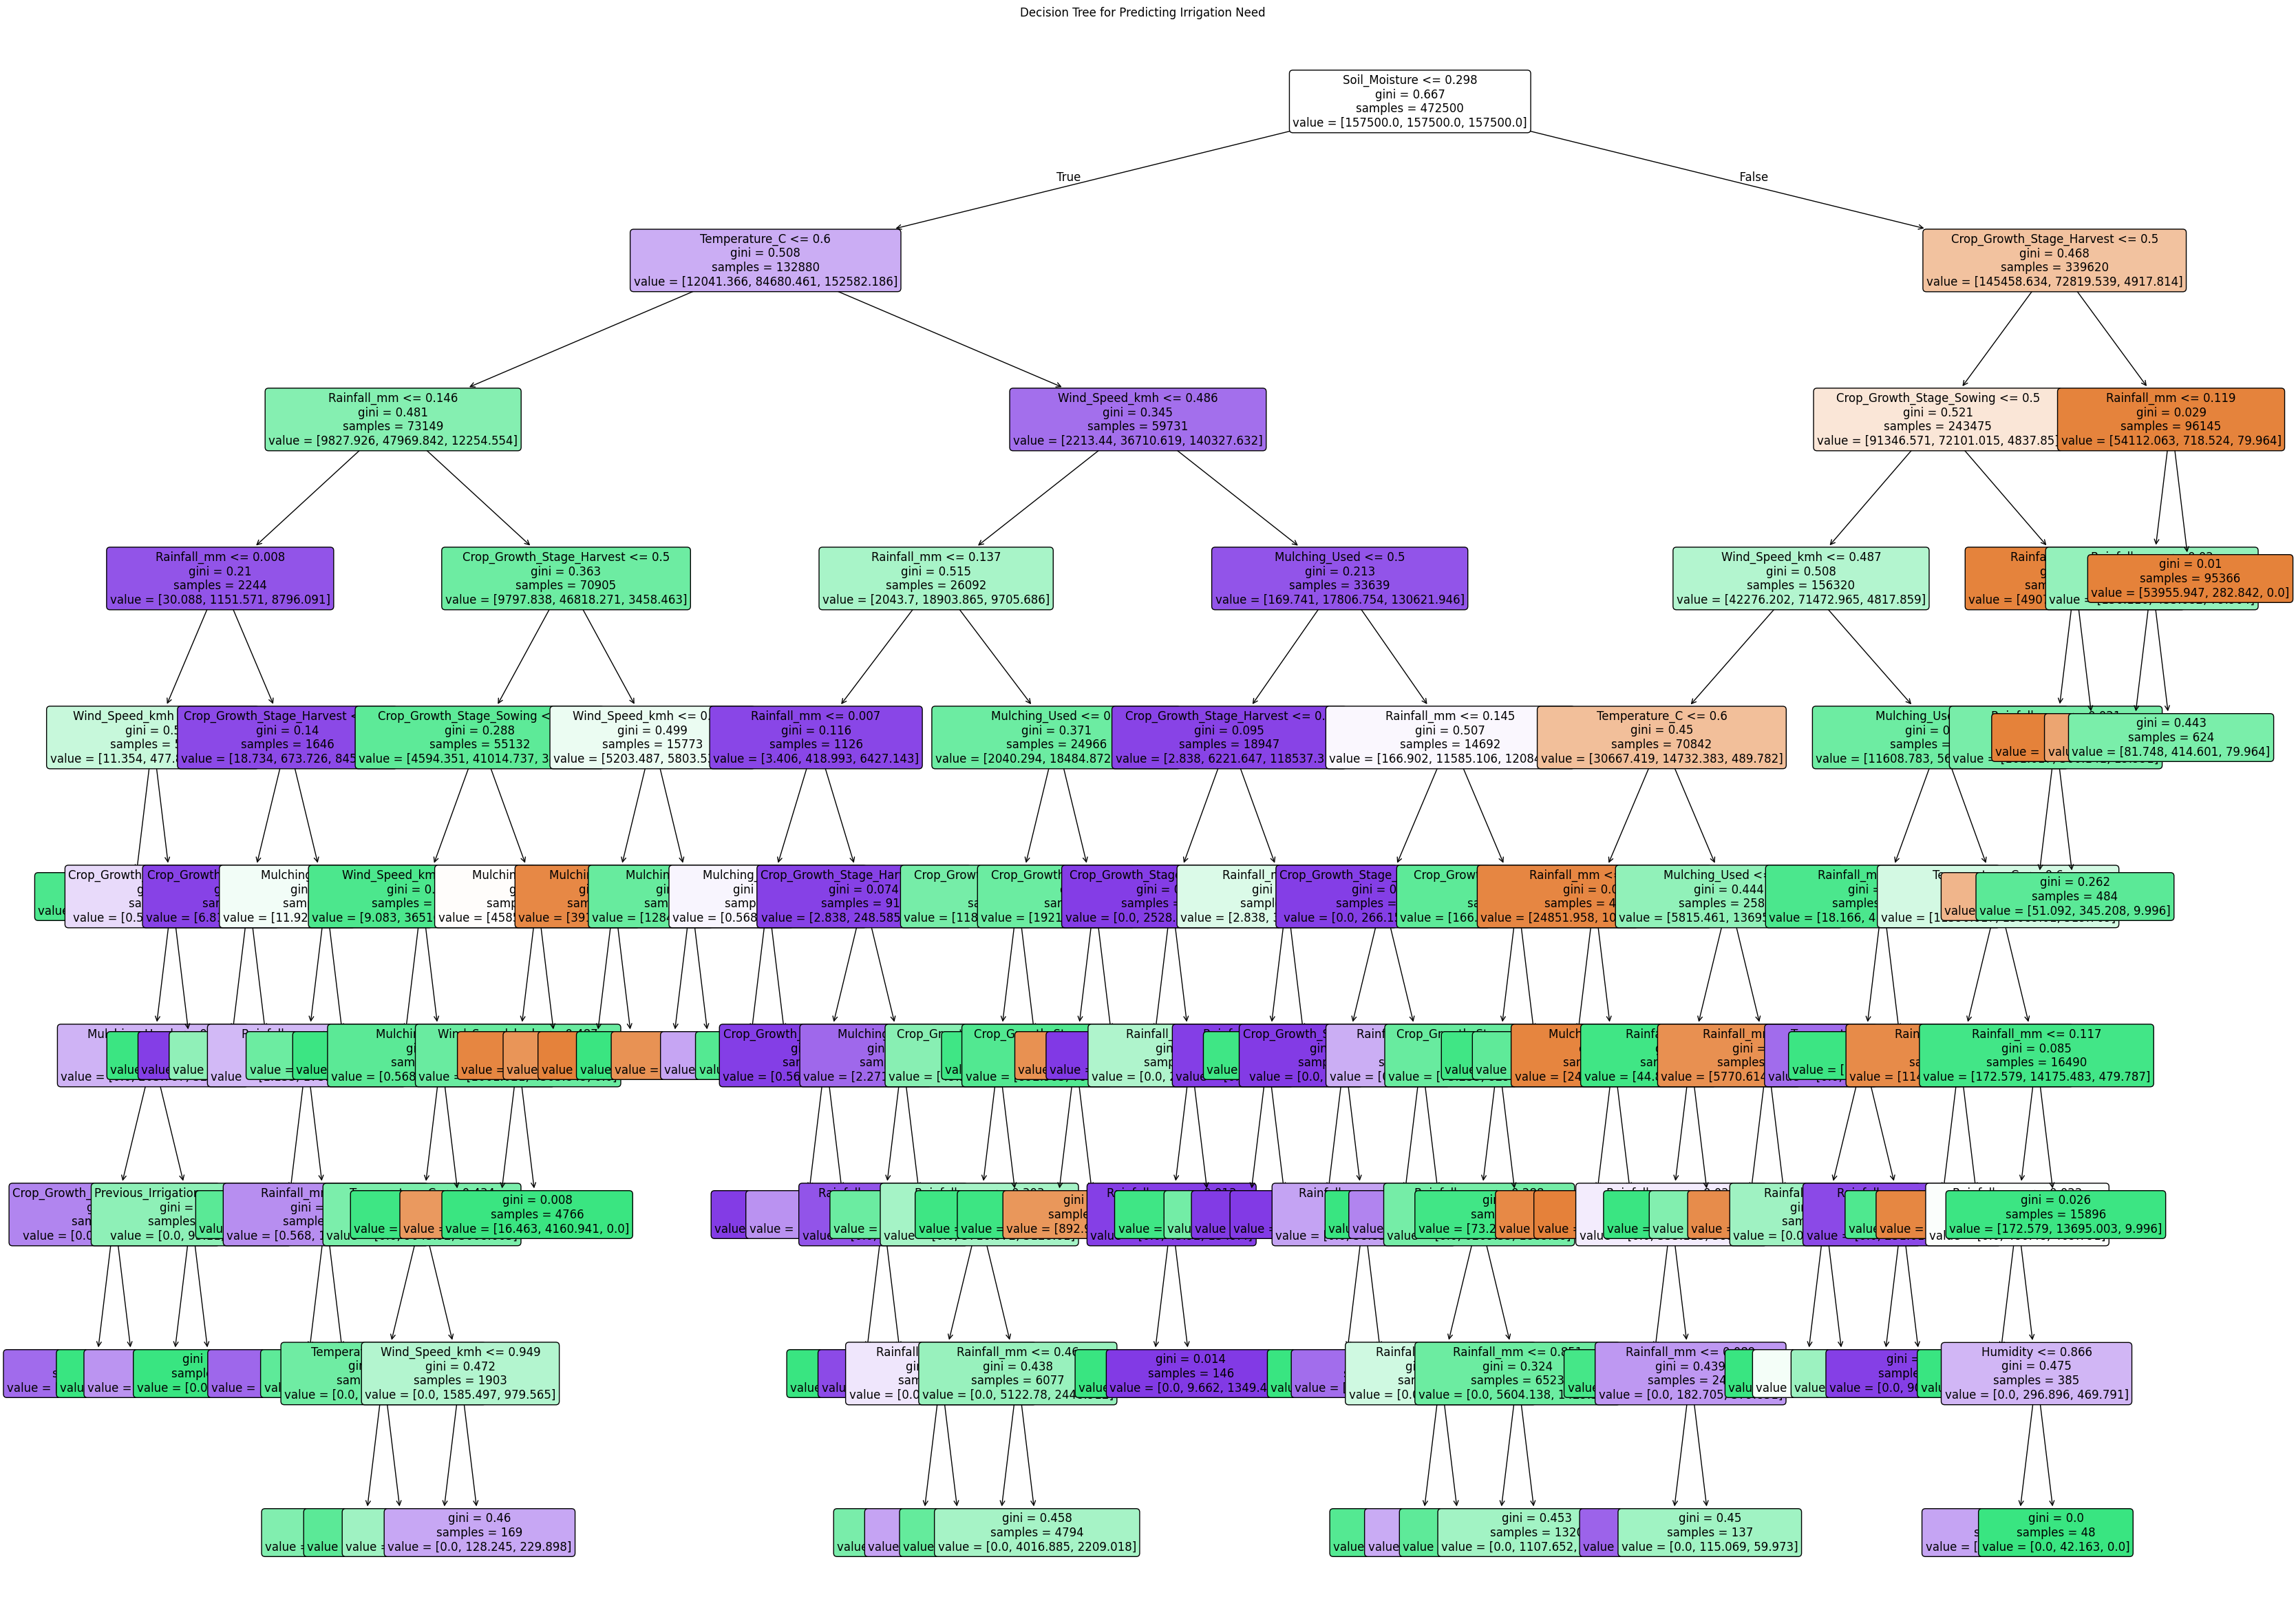

In [19]:
plt.figure(figsize=(40, 30))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    #class_names=['High', 'Medium', 'Low'],
    filled=True,
    fontsize=12,
    rounded = True
)
plt.title("Decision Tree for Predicting Irrigation Need")
plt.show()

In [20]:
tree_model.fit(X, y)
y_pred_dt_synthetic = tree_model.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_dt_synthetic]
})
output.to_csv('submission_DT_synthetic.csv', index=False, header=True)

Public score: 0.96422

## Original Dataset

In [21]:
X = data_train_original.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )

In [22]:
for depth in range(5, 20, 1):
    tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth=depth
    )

    tree_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = tree_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_depth value: {depth} Balanced accuracy: {bal_acc:.4f}")

max_depth value: 5 Balanced accuracy: 0.8918
max_depth value: 6 Balanced accuracy: 0.9366
max_depth value: 7 Balanced accuracy: 0.9924
max_depth value: 8 Balanced accuracy: 0.9924
max_depth value: 9 Balanced accuracy: 0.9885
max_depth value: 10 Balanced accuracy: 0.9888
max_depth value: 11 Balanced accuracy: 0.9885
max_depth value: 12 Balanced accuracy: 0.9885
max_depth value: 13 Balanced accuracy: 0.9885
max_depth value: 14 Balanced accuracy: 0.9885
max_depth value: 15 Balanced accuracy: 0.9885
max_depth value: 16 Balanced accuracy: 0.9885
max_depth value: 17 Balanced accuracy: 0.9885
max_depth value: 18 Balanced accuracy: 0.9885
max_depth value: 19 Balanced accuracy: 0.9885


In [23]:
for leaf_nodes in range(10, 100, 5):
    tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_leaf_nodes=leaf_nodes
    )

    tree_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = tree_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_leaf_nodes value: {leaf_nodes} Balanced accuracy: {bal_acc:.4f}")

max_leaf_nodes value: 10 Balanced accuracy: 0.8104
max_leaf_nodes value: 15 Balanced accuracy: 0.8777
max_leaf_nodes value: 20 Balanced accuracy: 0.9417
max_leaf_nodes value: 25 Balanced accuracy: 0.9560
max_leaf_nodes value: 30 Balanced accuracy: 0.9715
max_leaf_nodes value: 35 Balanced accuracy: 0.9796
max_leaf_nodes value: 40 Balanced accuracy: 0.9873
max_leaf_nodes value: 45 Balanced accuracy: 0.9912
max_leaf_nodes value: 50 Balanced accuracy: 0.9924
max_leaf_nodes value: 55 Balanced accuracy: 0.9931
max_leaf_nodes value: 60 Balanced accuracy: 0.9899
max_leaf_nodes value: 65 Balanced accuracy: 0.9902
max_leaf_nodes value: 70 Balanced accuracy: 0.9902
max_leaf_nodes value: 75 Balanced accuracy: 0.9902
max_leaf_nodes value: 80 Balanced accuracy: 0.9902
max_leaf_nodes value: 85 Balanced accuracy: 0.9902
max_leaf_nodes value: 90 Balanced accuracy: 0.9902
max_leaf_nodes value: 95 Balanced accuracy: 0.9902


In [24]:
#Defining a DecisionTreeClassifier with the optimal parameters
tree_model = DecisionTreeClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth = 8,
        max_leaf_nodes=55
    )

tree_model.fit(X_train, y_train)
# Predict and evaluate balanced accuracy on the validation sample
y_pred = tree_model.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy for the classifier with optimized parameters: {bal_acc:.4f}")

Balanced accuracy for the classifier with optimized parameters: 0.9931


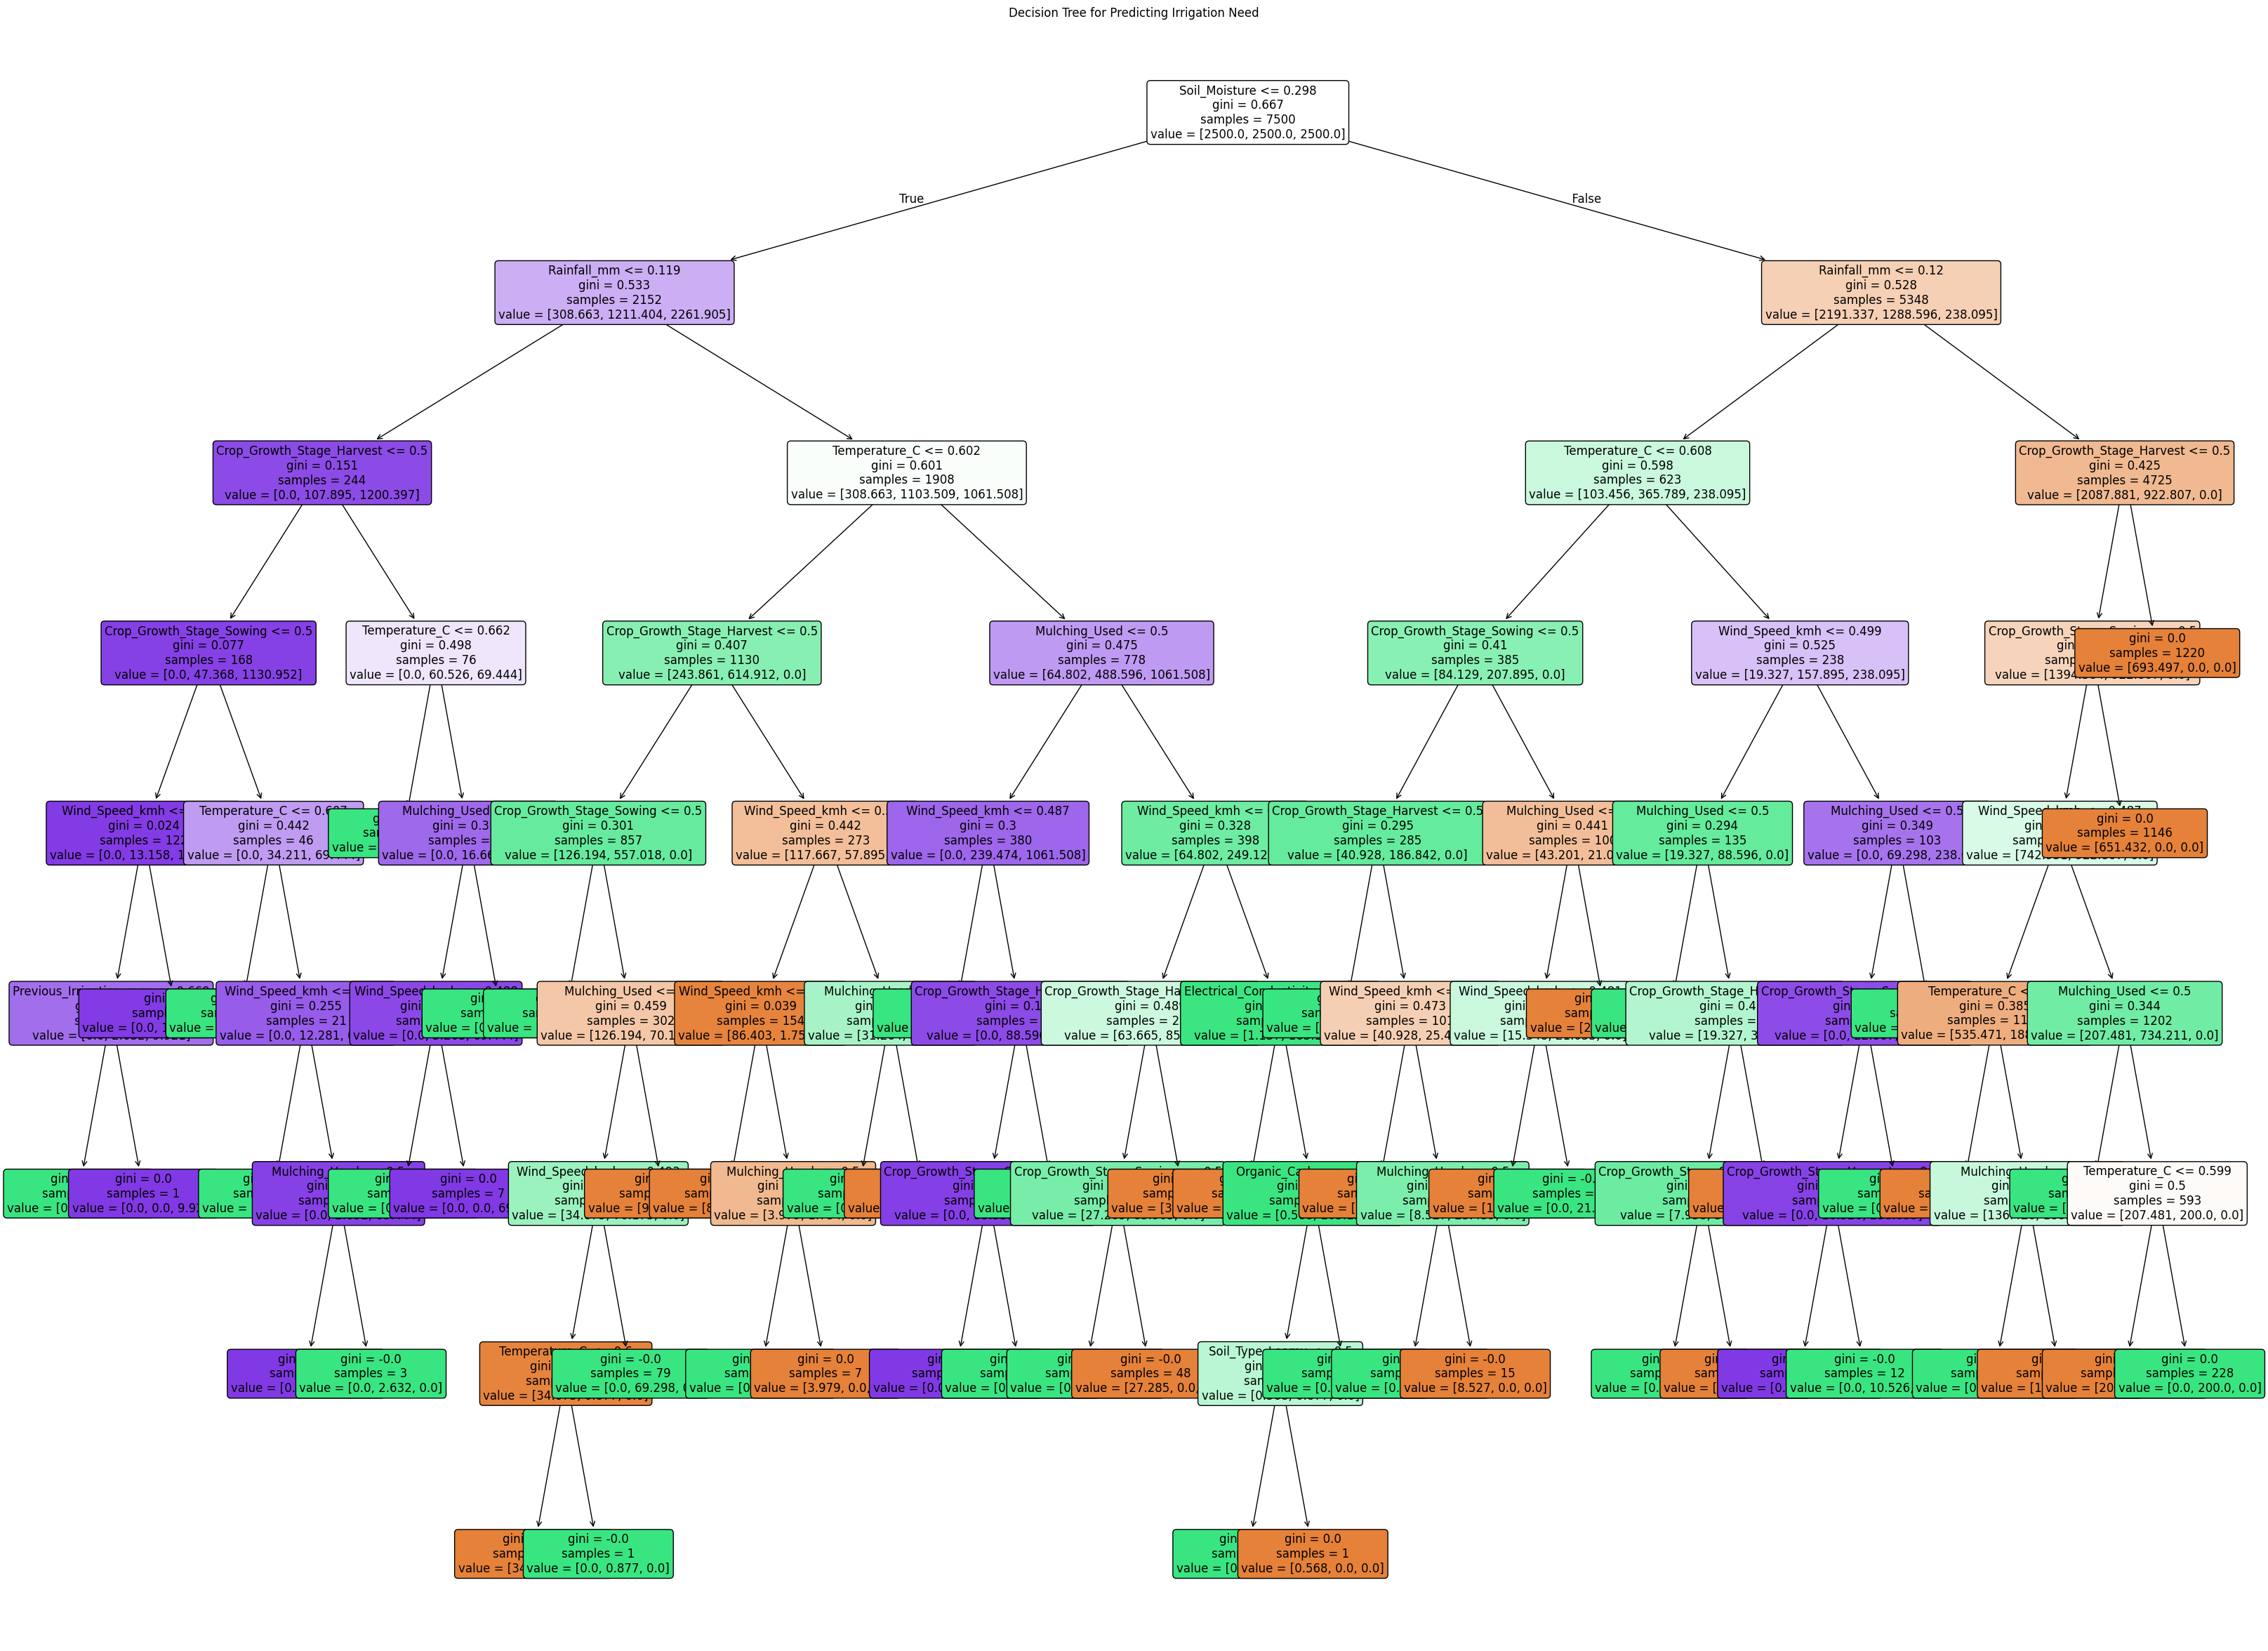

In [25]:
plt.figure(figsize=(40, 30))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    #class_names=['High', 'Medium', 'Low'],
    filled=True,
    fontsize=12,
    rounded = True
)
plt.title("Decision Tree for Predicting Irrigation Need")
plt.show()

In [26]:
tree_model.fit(X, y)
y_pred_dt_original = tree_model.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_dt_original]
})
output.to_csv('submission_DT_original.csv', index=False, header=True)

Public score: 0.95411

# RandomForest

## Synthetic dataset

In [27]:
X = data_train_synthetic.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )

In [28]:
for depth in range(5, 20, 1):
    RF_model = RandomForestClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth=depth
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_depth value: {depth} Balanced accuracy: {bal_acc:.4f}")

max_depth value: 5 Balanced accuracy: 0.9418
max_depth value: 6 Balanced accuracy: 0.9520
max_depth value: 7 Balanced accuracy: 0.9634
max_depth value: 8 Balanced accuracy: 0.9602
max_depth value: 9 Balanced accuracy: 0.9647
max_depth value: 10 Balanced accuracy: 0.9657
max_depth value: 11 Balanced accuracy: 0.9656
max_depth value: 12 Balanced accuracy: 0.9651
max_depth value: 13 Balanced accuracy: 0.9646
max_depth value: 14 Balanced accuracy: 0.9628
max_depth value: 15 Balanced accuracy: 0.9613
max_depth value: 16 Balanced accuracy: 0.9596
max_depth value: 17 Balanced accuracy: 0.9594
max_depth value: 18 Balanced accuracy: 0.9585
max_depth value: 19 Balanced accuracy: 0.9583


In [29]:
for n in [50, 100, 200, 500]:
    RF_model = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',   # to handle class imbalance
        random_state=37
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"n_estimators value: {n} Balanced accuracy: {bal_acc:.4f}")

n_estimators value: 50 Balanced accuracy: 0.9510
n_estimators value: 100 Balanced accuracy: 0.9539
n_estimators value: 200 Balanced accuracy: 0.9546
n_estimators value: 500 Balanced accuracy: 0.9548


In [30]:
for samples in [2, 5, 7, 10]:
    RF_model = RandomForestClassifier(
        min_samples_split=samples,
        class_weight='balanced',   # to handle class imbalance
        random_state=37
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"min_samples_split value: {samples} Balanced accuracy: {bal_acc:.4f}")

min_samples_split value: 2 Balanced accuracy: 0.9539
min_samples_split value: 5 Balanced accuracy: 0.9580
min_samples_split value: 7 Balanced accuracy: 0.9585
min_samples_split value: 10 Balanced accuracy: 0.9613


In [31]:
for samples in [12, 15, 17, 20]:
    RF_model = RandomForestClassifier(
        min_samples_split=samples,
        class_weight='balanced',   # to handle class imbalance
        random_state=37
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"min_samples_split value: {samples} Balanced accuracy: {bal_acc:.4f}")

min_samples_split value: 12 Balanced accuracy: 0.9617
min_samples_split value: 15 Balanced accuracy: 0.9635
min_samples_split value: 17 Balanced accuracy: 0.9634
min_samples_split value: 20 Balanced accuracy: 0.9643


In [32]:
RF_model = RandomForestClassifier(
    class_weight='balanced',   # to handle class imbalance
    random_state=37,
    max_depth=10,
    n_estimators= 500,
    min_samples_split=15
)

RF_model.fit(X_train, y_train)

# Predict and evaluate balanced accuracy
y_pred = RF_model.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy for the RandomForestClassifier with optimized parameters: {bal_acc:.4f}")

Balanced accuracy for the RandomForestClassifier with optimized parameters: 0.9659


In [33]:
RF_model.fit(X, y)
y_pred_rf_synthetic = RF_model.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_rf_synthetic]
})
output.to_csv('submission_RF_synthetic.csv', index=False, header=True)

## Original Dataset

In [34]:
X = data_train_original.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )

In [35]:
for depth in range(5, 15, 1):
    RF_model = RandomForestClassifier(
        class_weight='balanced',   # to handle class imbalance
        random_state=37,
        max_depth=depth
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"max_depth value: {depth} Balanced accuracy: {bal_acc:.4f}")

max_depth value: 5 Balanced accuracy: 0.9232
max_depth value: 6 Balanced accuracy: 0.9447
max_depth value: 7 Balanced accuracy: 0.9310
max_depth value: 8 Balanced accuracy: 0.9072
max_depth value: 9 Balanced accuracy: 0.8720
max_depth value: 10 Balanced accuracy: 0.8418
max_depth value: 11 Balanced accuracy: 0.8444
max_depth value: 12 Balanced accuracy: 0.8178
max_depth value: 13 Balanced accuracy: 0.8031
max_depth value: 14 Balanced accuracy: 0.8034


In [36]:
for n in [50, 100, 200, 500, 1000]:
    RF_model = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',   # to handle class imbalance
        random_state=37
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"n_estimators value: {n} Balanced accuracy: {bal_acc:.4f}")

n_estimators value: 50 Balanced accuracy: 0.7520
n_estimators value: 100 Balanced accuracy: 0.7510
n_estimators value: 200 Balanced accuracy: 0.7495
n_estimators value: 500 Balanced accuracy: 0.7549
n_estimators value: 1000 Balanced accuracy: 0.7538


In [37]:
for samples in [2, 5, 7, 10, 12, 15, 17, 20]:
    RF_model = RandomForestClassifier(
        min_samples_split=samples,
        class_weight='balanced',   # to handle class imbalance
        random_state=37
    )

    RF_model.fit(X_train, y_train)

    # Predict and evaluate balanced accuracy
    y_pred = RF_model.predict(X_valid)
    bal_acc = balanced_accuracy_score(y_valid, y_pred)
    print(f"min_samples_split value: {samples} Balanced accuracy: {bal_acc:.4f}")

min_samples_split value: 2 Balanced accuracy: 0.7510
min_samples_split value: 5 Balanced accuracy: 0.8195
min_samples_split value: 7 Balanced accuracy: 0.8195
min_samples_split value: 10 Balanced accuracy: 0.8531
min_samples_split value: 12 Balanced accuracy: 0.8641
min_samples_split value: 15 Balanced accuracy: 0.8770
min_samples_split value: 17 Balanced accuracy: 0.9060
min_samples_split value: 20 Balanced accuracy: 0.8902


In [38]:
RF_model = RandomForestClassifier(
    class_weight='balanced',   # to handle class imbalance
    random_state=37,
    max_depth=6,
    n_estimators= 500,
    min_samples_split=17
)

RF_model.fit(X_train, y_train)

# Predict and evaluate balanced accuracy
y_pred = RF_model.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy for the RandomForestClassifier with optimized parameters: {bal_acc:.4f}")

Balanced accuracy for the RandomForestClassifier with optimized parameters: 0.9583


In [39]:
RF_model.fit(X, y)
y_pred_rf_original = RF_model.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_rf_original]
})
output.to_csv('submission_RF_original.csv', index=False, header=True)

# XGBoost Classification Modeling and Prediction

## Synthetic Dataset

In [40]:
X = data_train_synthetic.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )

In [41]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [42]:
model_XGB = XGBClassifier(
    objective='multi:softprob',   # outputs probabilities
    num_class=3,
    eval_metric='mlogloss',       # multi-class log loss
    random_state=37,
    use_label_encoder=False       
)

model_XGB.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Predict and evaluate balanced accuracy
y_pred = model_XGB.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy: {bal_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:50:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced accuracy: 0.9700


In [43]:
y_pred_xgboost_synthetic = model_XGB.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_xgboost_synthetic]
})
output.to_csv('submission_XGB_synthetic.csv', index=False, header=True)

0.9562

## Original Dataset

In [44]:
X = data_train_original.copy()
y =X.pop("Irrigation_Need")
# Define the training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 37, 
                                                      test_size=0.25,  # 25% for testing
                                                      stratify=y #to account for class imbalance
                                                     )
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [45]:
model_XGB = XGBClassifier(
    objective='multi:softprob',   # outputs probabilities
    num_class=3,
    eval_metric='mlogloss',       # multi-class log loss
    random_state=37,
    use_label_encoder=False       # avoids warning
)

model_XGB.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Predict and evaluate balanced accuracy
y_pred = model_XGB.predict(X_valid)
bal_acc = balanced_accuracy_score(y_valid, y_pred)
print(f"Balanced accuracy: {bal_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:50:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced accuracy: 0.9911


In [46]:
y_pred_xgboost_original = model_XGB.predict(data_test)
output = pd.DataFrame({ "id": data_test.index,
    "Irrigation_Need": [inverse_low_medium_high_mapping[i] for i in y_pred_xgboost_original]
})
output.to_csv('submission_XGB_original.csv', index=False, header=True)

Public score: 0.9669